In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

In [2]:
PATH = 'data'
sleep = pd.read_csv(f"{PATH}/sleep12.csv", skiprows=1, index_col=False, on_bad_lines='skip')
sleep = sleep.rename(columns={'com.samsung.health.sleep.end_time': 'date'})
sleep = sleep.loc[:, ~sleep.columns.str.contains('^Unnamed')]
sleep['date'] = pd.to_datetime(sleep['date']).dt.normalize()
sleep

,total_sleep_time_weight,original_efficiency,mental_recovery,wake_score,factor_01,factor_02,factor_03,factor_04,factor_05,factor_06,...,com.samsung.health.sleep.update_time,com.samsung.health.sleep.create_time,com.samsung.health.sleep.client_data_id,com.samsung.health.sleep.client_data_ver,com.samsung.health.sleep.time_offset,com.samsung.health.sleep.deviceuuid,com.samsung.health.sleep.comment,com.samsung.health.sleep.pkg_name,date,com.samsung.health.sleep.datauuid
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2021-08-07 16:27:14.981,2021-08-07 16:27:14.981,NaN,NaN,UTC+0300,bWj3B5w0Pp,NaN,com.sec.android.app.shealth,2021-08-07,3402b213-2707-4323-befa-5429ca1742ef
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2021-08-29 13:21:08.598,2021-08-29 13:21:08.598,NaN,NaN,UTC+0300,bWj3B5w0Pp,NaN,com.sec.android.app.shealth,2021-08-29,75e086df-26f4-43cf-83e0-b0b56c00f879
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2024-03-05 20:45:54.990,2024-03-05 20:45:54.990,NaN,NaN,UTC+0300,bWj3B5w0Pp,NaN,com.sec.android.app.shealth,2024-03-05,00ec8101-af56-4443-a850-25ae0e38b3cd
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2024-05-24 16:44:19.309,2024-05-24 16:44:19.309,NaN,NaN,UTC+0300,bWj3B5w0Pp,NaN,com.sec.android.app.shealth,2024-05-24,05ea9269-388f-47c5-9122-91f592cf091f
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2024-05-25 15:27:40.553,2024-05-25 15:27:40.553,NaN,NaN,UTC+0300,bWj3B5w0Pp,NaN,com.sec.android.app.shealth,2024-05-25,73def407-e0db-45be-b05f-d3a40a2a9155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,34.0,NaN,87.0,6.0,73.0,136.0,5.0,1.0,18.0,430.0,...,2025-12-08 05:02:50.730,2025-12-08 04:55:33.676,NaN,NaN,UTC+0300,IChoSlfqVi,NaN,com.sec.android.app.shealth,2025-12-08,a201f7a5-0d52-4646-82a7-423f008554b4
298,34.0,NaN,93.0,6.0,19.0,92.0,2.0,2.0,13.0,370.0,...,2025-12-09 04:07:25.329,2025-12-09 04:07:17.198,NaN,NaN,UTC+0300,IChoSlfqVi,NaN,com.sec.android.app.shealth,2025-12-09,c88ab999-1a33-4b0b-8623-cdd785b96aa7
299,34.0,NaN,93.0,6.0,64.0,115.0,9.0,4.0,21.0,412.0,...,2025-12-10 04:25:58.146,2025-12-10 04:25:35.988,NaN,NaN,UTC+0300,IChoSlfqVi,NaN,com.sec.android.app.shealth,2025-12-10,5db51cf8-0e61-4868-9239-51f842caa3c0
300,34.0,NaN,93.0,6.0,37.0,119.0,1.0,3.0,12.0,404.0,...,2025-12-11 04:35:36.330,2025-12-11 04:35:11.250,NaN,NaN,UTC+0300,IChoSlfqVi,NaN,com.sec.android.app.shealth,2025-12-11,91241a68-5697-4c84-9679-caad81b7e91e


In [3]:
# There are some data before 2024 or with sleep duration = 0, they are useless to my study.
sleep = sleep[(sleep['date'] > pd.to_datetime('2024-10-01')) & (sleep['sleep_duration'] > 0)] 
sleep

,total_sleep_time_weight,original_efficiency,mental_recovery,wake_score,factor_01,factor_02,factor_03,factor_04,factor_05,factor_06,...,com.samsung.health.sleep.update_time,com.samsung.health.sleep.create_time,com.samsung.health.sleep.client_data_id,com.samsung.health.sleep.client_data_ver,com.samsung.health.sleep.time_offset,com.samsung.health.sleep.deviceuuid,com.samsung.health.sleep.comment,com.samsung.health.sleep.pkg_name,date,com.samsung.health.sleep.datauuid
19,NaN,NaN,82.0,NaN,6.0,23.0,6.0,1.0,7.0,220.0,...,2024-11-02 06:18:52.689,2024-11-02 02:05:42.626,NaN,NaN,UTC+0300,KCkzhBg4bx,NaN,com.sec.android.app.shealth,2024-11-02,fa45f3a7-c636-4724-9fe2-c0e3ac7124ea
20,NaN,NaN,53.0,NaN,34.0,34.0,16.0,0.0,19.0,231.0,...,2024-11-02 06:18:52.697,2024-11-02 06:18:46.296,NaN,NaN,UTC+0300,KCkzhBg4bx,NaN,com.sec.android.app.shealth,2024-11-02,0f83546a-94a6-4cb6-8fe9-0ff843616605
21,NaN,NaN,97.0,NaN,28.0,105.0,1.0,1.0,48.0,531.0,...,2024-11-03 07:12:25.328,2024-11-03 07:12:14.535,NaN,NaN,UTC+0300,KCkzhBg4bx,NaN,com.sec.android.app.shealth,2024-11-03,d5a2a067-71c3-47c9-9bc3-c67ed9b5b176
22,NaN,NaN,89.0,NaN,49.0,49.0,8.0,1.0,8.0,293.0,...,2024-11-04 04:58:06.737,2024-11-04 03:43:55.981,NaN,NaN,UTC+0300,KCkzhBg4bx,NaN,com.sec.android.app.shealth,2024-11-04,5e359ae2-e000-4356-8f4c-8db67ce51ef5
23,NaN,NaN,6.0,NaN,17.0,17.0,4.0,0.0,4.0,67.0,...,2024-11-04 04:58:06.816,2024-11-04 04:58:03.722,NaN,NaN,UTC+0300,KCkzhBg4bx,NaN,com.sec.android.app.shealth,2024-11-04,d8db437f-e2b0-4ec1-a4c6-e03de0a00faf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,34.0,NaN,87.0,6.0,73.0,136.0,5.0,1.0,18.0,430.0,...,2025-12-08 05:02:50.730,2025-12-08 04:55:33.676,NaN,NaN,UTC+0300,IChoSlfqVi,NaN,com.sec.android.app.shealth,2025-12-08,a201f7a5-0d52-4646-82a7-423f008554b4
298,34.0,NaN,93.0,6.0,19.0,92.0,2.0,2.0,13.0,370.0,...,2025-12-09 04:07:25.329,2025-12-09 04:07:17.198,NaN,NaN,UTC+0300,IChoSlfqVi,NaN,com.sec.android.app.shealth,2025-12-09,c88ab999-1a33-4b0b-8623-cdd785b96aa7
299,34.0,NaN,93.0,6.0,64.0,115.0,9.0,4.0,21.0,412.0,...,2025-12-10 04:25:58.146,2025-12-10 04:25:35.988,NaN,NaN,UTC+0300,IChoSlfqVi,NaN,com.sec.android.app.shealth,2025-12-10,5db51cf8-0e61-4868-9239-51f842caa3c0
300,34.0,NaN,93.0,6.0,37.0,119.0,1.0,3.0,12.0,404.0,...,2025-12-11 04:35:36.330,2025-12-11 04:35:11.250,NaN,NaN,UTC+0300,IChoSlfqVi,NaN,com.sec.android.app.shealth,2025-12-11,91241a68-5697-4c84-9679-caad81b7e91e


In [4]:
# There are more rows than I expected, I want to check duplicate count for each date.
sleep.groupby('date')['date'].count().sort_values(ascending=False)

date
2024-11-02    2
2025-06-20    2
2025-09-13    2
2025-11-02    2
2025-08-04    2
             ..
2025-04-10    1
2025-04-11    1
2025-04-14    1
2025-04-15    1
2025-12-12    1
Name: date, Length: 248, dtype: int64

In [5]:
# Dates that I napped, these will be aggregated as sum.
sleep[sleep['date'].isin(['2024-11-02', '2025-06-20', '2025-09-13', '2025-11-02', '2025-08-04'])].sort_values('date').loc[:, ['date', 'sleep_duration']]

/var/folders/5d/9l6gb_c515qgg88vn1bg1y340000gn/T/ipykernel_51262/3491867299.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  sleep[sleep['date'].isin(['2024-11-02', '2025-06-20', '2025-09-13', '2025-11-02', '2025-08-04'])].sort_values('date').loc[:, ['date', 'sleep_duration']]


,date,sleep_duration
19,2024-11-02,220.0
20,2024-11-02,231.0
181,2025-06-20,315.0
182,2025-06-20,83.0
210,2025-08-04,238.0
211,2025-08-04,173.0
235,2025-09-13,400.0
236,2025-09-13,181.0
272,2025-11-02,496.0
273,2025-11-02,165.0


In [6]:
steps = pd.read_csv(f"{PATH}/steps12.csv", skiprows=2, index_col=False)
steps = steps.loc[:, ~steps.columns.str.contains('^Unnamed')]
steps['update_time'] = pd.to_datetime(steps['update_time']).dt.normalize()
steps = steps[steps['update_time'] > pd.to_datetime('2024-10-01')] # To match the sleep dates
steps

,binning_data,update_time,create_time,source_pkg_name,source_type,count,speed,distance,calorie,deviceuuid,pkg_name,datauuid,day_time
3693,741c0bcf-1606-4778-8782-7ccc70bd0f59.binning_d...,2024-10-02,2024-10-01 21:12:23.320,com.sec.android.app.shealth,-2,7231,1.311924,5276.82,225.31000,VfS0qUERdZ,com.sec.android.app.shealth,741c0bcf-1606-4778-8782-7ccc70bd0f59,1727827200000
3694,03326f60-4e34-4db4-9aad-7e6e6d282afd.binning_d...,2024-10-02,2024-10-01 21:12:26.493,com.sec.android.app.shealth,0,7231,1.311924,5276.82,225.31000,sL+KSz6/E2,com.sec.android.app.shealth,03326f60-4e34-4db4-9aad-7e6e6d282afd,1727827200000
3696,2567bbcf-5ab0-4af5-bfaf-68fa1292ab88.binning_d...,2024-10-03,2024-10-02 21:12:47.530,com.sec.android.app.shealth,-2,7178,1.333443,5254.10,222.59999,VfS0qUERdZ,com.sec.android.app.shealth,2567bbcf-5ab0-4af5-bfaf-68fa1292ab88,1727913600000
3697,b33c7c35-76bf-44c1-afbf-debacc30a783.binning_d...,2024-10-03,2024-10-03 21:00:03.106,com.sec.android.app.shealth,0,7178,1.333443,5254.10,222.59999,sL+KSz6/E2,com.sec.android.app.shealth,b33c7c35-76bf-44c1-afbf-debacc30a783,1727913600000
3698,2066da27-fa3c-4438-b68d-d8fb0f3ccf6f.binning_d...,2024-10-04,2024-10-04 05:00:01.788,com.sec.android.app.shealth,-2,8088,1.363549,5952.63,249.68000,VfS0qUERdZ,com.sec.android.app.shealth,2066da27-fa3c-4438-b68d-d8fb0f3ccf6f,1728000000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4884,fc9d48e7-31c0-4d69-9aaa-6ff1fcc0e6c9.binning_d...,2025-12-13,2025-12-12 05:46:38.572,com.sec.android.app.shealth,-2,7294,1.413843,5554.07,238.54000,VfS0qUERdZ,com.sec.android.app.shealth,fc9d48e7-31c0-4d69-9aaa-6ff1fcc0e6c9,1765497600000
4885,2bc3218b-64fa-4fe1-a623-13f91b6cb172.binning_d...,2025-12-12,2025-12-12 21:00:04.251,com.sec.android.app.shealth,0,6328,1.398821,4807.26,199.32999,sL+KSz6/E2,com.sec.android.app.shealth,2bc3218b-64fa-4fe1-a623-13f91b6cb172,1765497600000
4886,47dad904-da70-406d-be45-a6b632e57ea5.binning_d...,2025-12-13,2025-12-12 21:00:08.082,com.sec.android.app.shealth,111,6792,1.452166,5200.50,225.80000,IChoSlfqVi,com.sec.android.app.shealth,47dad904-da70-406d-be45-a6b632e57ea5,1765497600000
4887,1c5cc1f0-9ec3-420f-a703-05027934b405.binning_d...,2025-12-13,2025-12-13 11:56:17.622,com.sec.android.app.shealth,-2,79,2.090950,85.70,4.53000,VfS0qUERdZ,com.sec.android.app.shealth,1c5cc1f0-9ec3-420f-a703-05027934b405,1765584000000


In [7]:
steps.groupby('update_time')['update_time'].count().sort_values(ascending=False) # Steps data should also be aggregated

update_time
2025-04-16    6
2025-10-13    6
2025-01-08    5
2025-08-01    5
2025-09-17    5
             ..
2025-01-23    1
2024-11-16    1
2025-10-02    1
2025-03-06    1
2025-04-14    1
Name: update_time, Length: 436, dtype: int64

In [8]:
# Rows here for the same date represent updated cumulative values. Instead of summing them up, max value should be taken.
steps[steps['update_time'].isin(['2025-04-16', '2025-10-13', '2025-01-08', '2025-08-01', '2025-09-17'])].sort_values('update_time').loc[:, ['update_time', 'count']]

/var/folders/5d/9l6gb_c515qgg88vn1bg1y340000gn/T/ipykernel_51262/3680482939.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  steps[steps['update_time'].isin(['2025-04-16', '2025-10-13', '2025-01-08', '2025-08-01', '2025-09-17'])].sort_values('update_time').loc[:, ['update_time', 'count']]


,update_time,count
3950,2025-01-08,14067
3952,2025-01-08,13195
3953,2025-01-08,9425
3954,2025-01-08,8764
3955,2025-01-08,8243
4219,2025-04-16,5479
4220,2025-04-16,5928
4221,2025-04-16,7598
4222,2025-04-16,7144
4224,2025-04-16,6582


In [9]:
# Aggregating target columns and resetting indexes so that I can use date columns, I don't want them as indexes.
daily_steps = steps.groupby('update_time')['count'].max().reset_index() 
daily_sleep = sleep.groupby('date')[['sleep_duration', 'total_rem_duration']].sum().reset_index()
# Converting minutes to hours
daily_sleep['daily_sleep_hours'] = daily_sleep['sleep_duration'] / 60 
daily_sleep['daily_rem_hours'] = daily_sleep['total_rem_duration'] / 60
daily_sleep

,date,sleep_duration,total_rem_duration,daily_sleep_hours,daily_rem_hours
0,2024-11-02,451.0,88.0,7.516667,1.466667
1,2024-11-03,531.0,159.0,8.850000,2.650000
2,2024-11-04,360.0,77.0,6.000000,1.283333
3,2024-11-05,433.0,92.0,7.216667,1.533333
4,2024-11-06,396.0,126.0,6.600000,2.100000
...,...,...,...,...,...
243,2025-12-08,430.0,79.0,7.166667,1.316667
244,2025-12-09,370.0,105.0,6.166667,1.750000
245,2025-12-10,412.0,112.0,6.866667,1.866667
246,2025-12-11,404.0,106.0,6.733333,1.766667


In [10]:
daily_steps.describe()

,update_time,count
count,436,436.000000
mean,2025-05-08 00:13:12.660550400,8046.582569
min,2024-10-02 00:00:00,18.000000
25%,2025-01-18 18:00:00,5982.500000
50%,2025-05-07 12:00:00,8466.500000
75%,2025-08-25 06:00:00,11357.000000
max,2025-12-13 00:00:00,22202.000000
std,NaN,4739.765657


--- STATISTICS BY MONTH ---
           daily_sleep_hours             daily_rem_hours            
                        mean   std count            mean   std count
year_month                                                          
2024-11                 7.30  1.23    29            1.90  0.59    29
2024-12                 7.10  1.12    26            1.72  0.40    26
2025-01                 6.73  1.30    15            1.66  0.56    15
2025-02                 6.81  0.80     8            1.65  0.35     8
2025-03                 7.14  0.54     4            1.98  0.30     4
2025-04                 6.61  0.81    20            1.54  0.38    20
2025-05                 6.58  0.84    19            1.47  0.44    19
2025-06                 6.84  0.58    18            1.70  0.44    18
2025-07                 6.74  0.51    21            1.75  0.24    21
2025-08                 6.58  1.10    20            1.64  0.53    20
2025-09                 7.30  1.17    18            1.77  0.48    18
2025-1

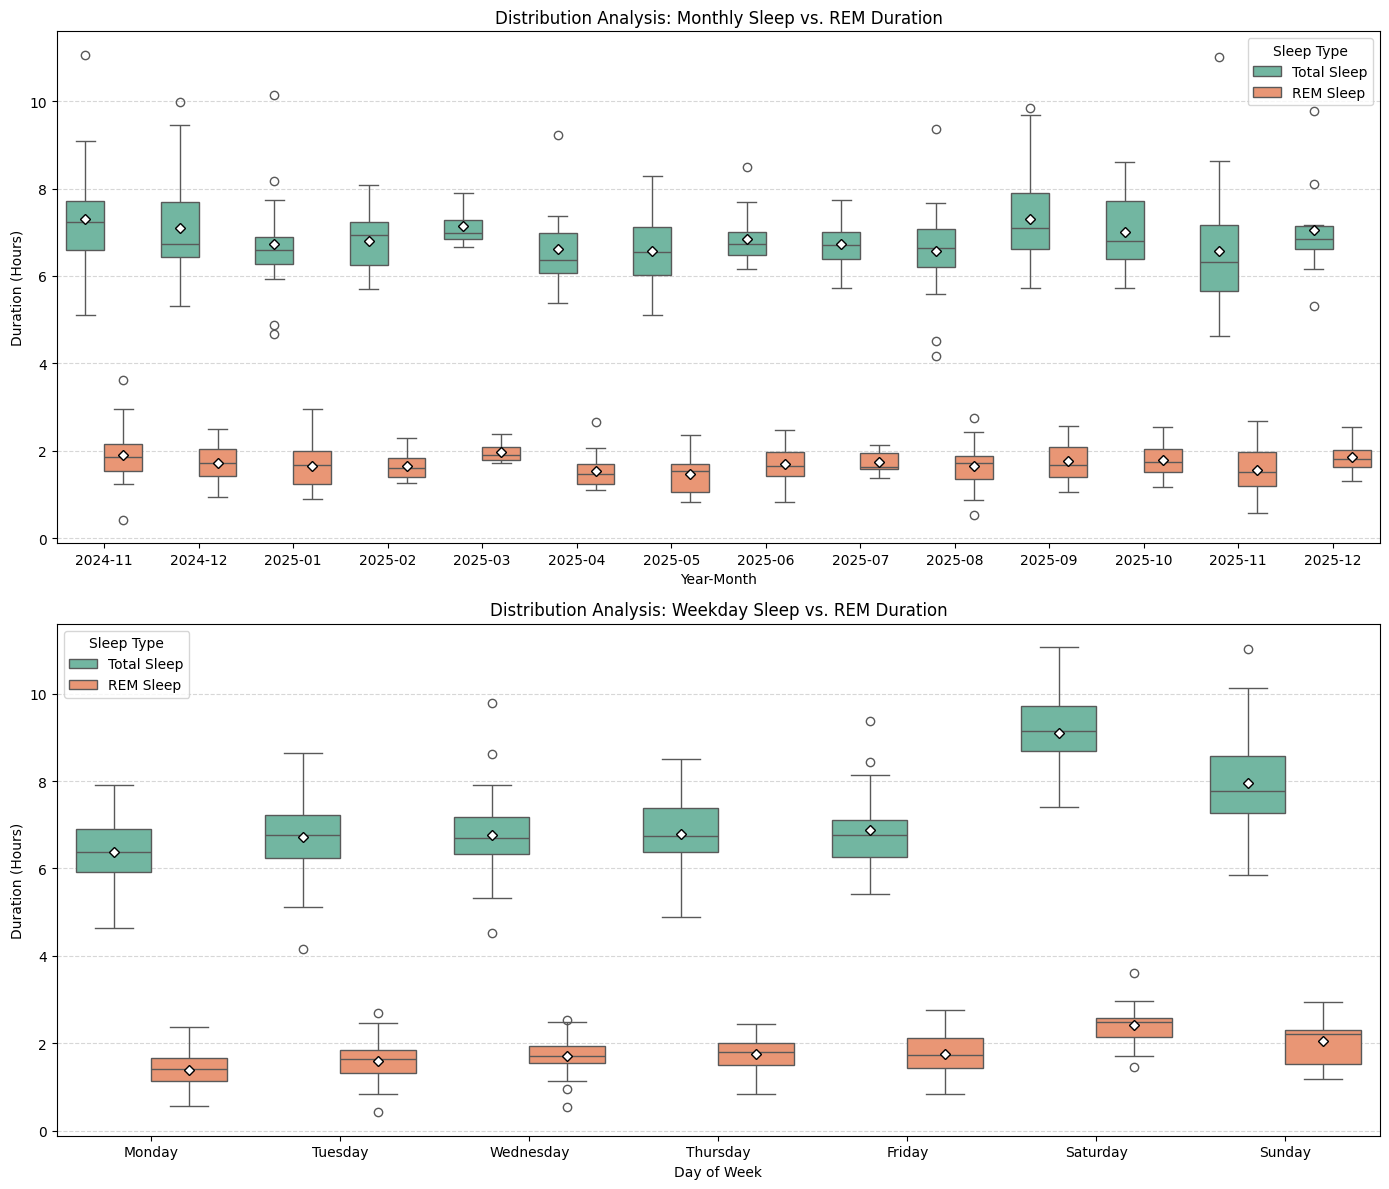

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Creating temporal features for aggregation.
daily_sleep['year_month'] = daily_sleep['date'].dt.to_period('M').astype(str)
daily_sleep['day_name'] = daily_sleep['date'].dt.day_name()
daily_sleep = daily_sleep.sort_values('date')

# Quantifying mean and stddev of sleep patterns.
stats_month = daily_sleep.groupby('year_month')[['daily_sleep_hours', 'daily_rem_hours']].agg(['mean', 'std', 'count']).round(2)
print("--- STATISTICS BY MONTH ---")
print(stats_month)

# Reindexing ensuring we follow the temporal cycle of the week, not alphabetical order.
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

stats_day = daily_sleep.groupby('day_name')[['daily_sleep_hours', 'daily_rem_hours']]\
    .agg(['count', 'mean', 'std'])\
    .reindex(day_order)\
    .round(2)

print("--- STATISTICS BY WEEKDAY ---")
print(stats_day)


# Melting the dataframe to long format. 
# This allows us to plot both "Total Sleep" and "REM Sleep" on the same Y-axis scale to visually compare their variances side by side.
df_melted = daily_sleep.melt(
    id_vars=['date', 'year_month', 'day_name'], 
    value_vars=['daily_sleep_hours', 'daily_rem_hours'],
    var_name='Sleep Type', 
    value_name='Duration (Hours)'
)

df_melted['Sleep Type'] = df_melted['Sleep Type'].replace({
    'daily_sleep_hours': 'Total Sleep', 
    'daily_rem_hours': 'REM Sleep'
})


fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Monthly Distribution
sns.boxplot(
    data=df_melted, 
    x='year_month', 
    y='Duration (Hours)', 
    hue='Sleep Type', 
    palette="Set2", 
    ax=axes[0], 
    showmeans=True, 
    dodge=True,
    meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize": 5}
)
axes[0].set_title('Distribution Analysis: Monthly Sleep vs. REM Duration')
axes[0].set_xlabel('Year-Month')
axes[0].set_ylabel('Duration (Hours)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Weekday Distribution
sns.boxplot(
    data=df_melted, 
    x='day_name', 
    y='Duration (Hours)', 
    hue='Sleep Type', 
    order=day_order, 
    palette="Set2", 
    ax=axes[1], 
    showmeans=True,
    dodge=True,
    meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":5}
)
axes[1].set_title('Distribution Analysis: Weekday Sleep vs. REM Duration')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Duration (Hours)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('distribution_stats_analysis.png', dpi=300)
plt.show()

--- STEP STATISTICS BY WEEKDAY ---
           count         mean          std
day_name                                  
Monday        62  8754.290323  2923.822270
Tuesday       62  9738.951613  4277.613044
Wednesday     63  9264.492063  3830.863420
Thursday      63  9315.571429  3063.628124
Friday        63  9580.619048  3267.431296
Saturday      62  7059.306452  5829.684736
Sunday        61  2457.852459  4814.020004
--- STEP STATISTICS BY MONTH ---
            count          mean          std
year_month                                  
2024-10        30   5477.866667  4046.191038
2024-11        30   7731.566667  3940.024809
2024-12        31   7875.032258  4502.147447
2025-01        31   6780.193548  4180.995842
2025-02        28   7767.750000  4497.990915
2025-03        31   6953.774194  4377.253878
2025-04        30   6854.066667  4132.425946
2025-05        30   6644.700000  3780.999596
2025-06        30   9378.800000  5420.267702
2025-07        31   8618.451613  4393.256483
2025-

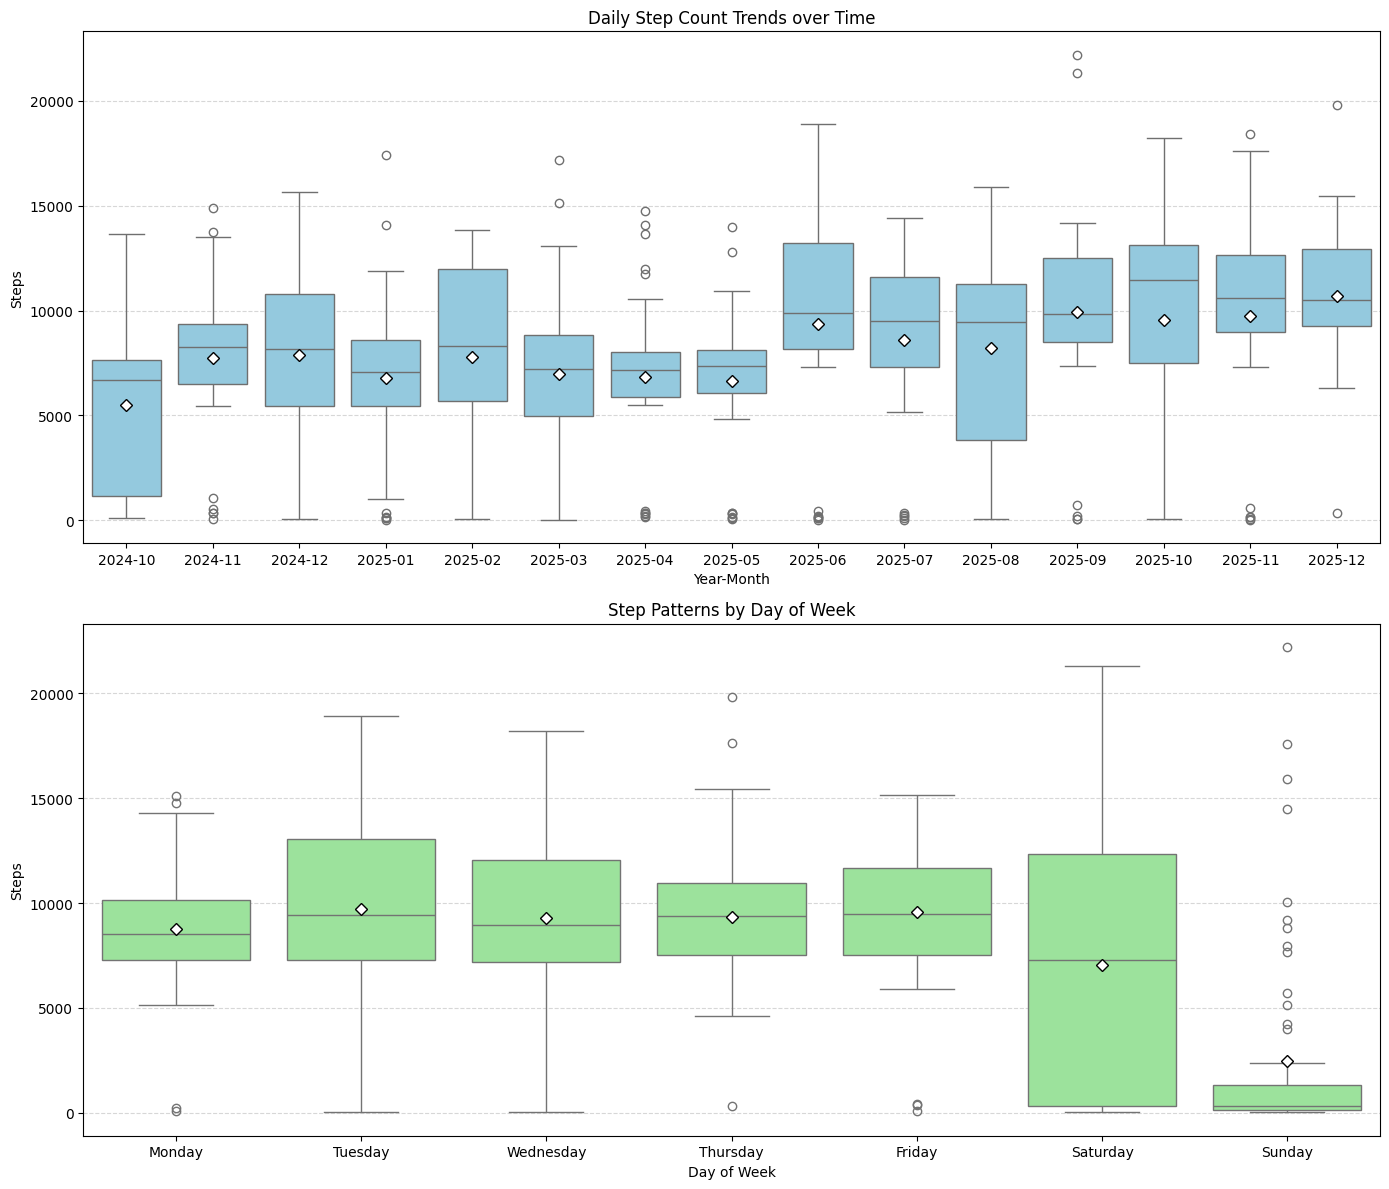

In [12]:
daily_steps['year_month'] = daily_steps['update_time'].dt.to_period('M').astype(str)
daily_steps['day_name'] = daily_steps['update_time'].dt.day_name()
daily_steps = daily_steps.sort_values('update_time')

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
stats_steps = daily_steps.groupby('day_name')['count'].agg(['count', 'mean', 'std']).reindex(day_order)

print("--- STEP STATISTICS BY WEEKDAY ---")
print(stats_steps)

stats_steps_month = daily_steps.groupby('year_month')['count'].agg(['count', 'mean', 'std'])
print("--- STEP STATISTICS BY MONTH ---")
print(stats_steps_month)

# VISUALIZATION
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Monthly Steps
sns.boxplot(data=daily_steps, x='year_month', y='count', 
            color='skyblue', ax=axes[0], showmeans=True,
            meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":6})
axes[0].set_title('Daily Step Count Trends over Time')
axes[0].set_ylabel('Steps')
axes[0].set_xlabel('Year-Month')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Weekday Steps
sns.boxplot(data=daily_steps, x='day_name', y='count', 
            order=day_order, color='lightgreen', ax=axes[1], showmeans=True,
            meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":6})
axes[1].set_title('Step Patterns by Day of Week')
axes[1].set_ylabel('Steps')
axes[1].set_xlabel('Day of Week')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('step_analysis.png', dpi=300)
plt.show()

In [13]:
daily_steps['join_date'] = daily_steps['update_time'] + pd.Timedelta(days=1) # So that I can join them as tomorrow's date.

merged_df = pd.merge(
    daily_sleep, 
    daily_steps[['join_date', 'count']], 
    left_on='date', 
    right_on='join_date',
    how='inner' # if there's no match, I don't want them
)

df = merged_df.dropna(subset=['daily_sleep_hours', 'daily_rem_hours', 'count']) # if there's any missing values, I don't want them either
df

,date,sleep_duration,total_rem_duration,daily_sleep_hours,daily_rem_hours,year_month,day_name,join_date,count
0,2024-11-02,451.0,88.0,7.516667,1.466667,2024-11,Saturday,2024-11-02,7312
1,2024-11-03,531.0,159.0,8.850000,2.650000,2024-11,Sunday,2024-11-03,5435
2,2024-11-04,360.0,77.0,6.000000,1.283333,2024-11,Monday,2024-11-04,5733
3,2024-11-05,433.0,92.0,7.216667,1.533333,2024-11,Tuesday,2024-11-05,6221
4,2024-11-06,396.0,126.0,6.600000,2.100000,2024-11,Wednesday,2024-11-06,13527
...,...,...,...,...,...,...,...,...,...
242,2025-12-08,430.0,79.0,7.166667,1.316667,2025-12,Monday,2025-12-08,340
243,2025-12-09,370.0,105.0,6.166667,1.750000,2025-12,Tuesday,2025-12-09,9727
244,2025-12-10,412.0,112.0,6.866667,1.866667,2025-12,Wednesday,2025-12-10,12299
245,2025-12-11,404.0,106.0,6.733333,1.766667,2025-12,Thursday,2025-12-11,12933


In [14]:
df[['daily_sleep_hours', 'daily_rem_hours', 'count']].describe() # Basic statistics of the joined data

,daily_sleep_hours,daily_rem_hours,count
count,247.000000,247.000000,247.000000
mean,6.892375,1.702294,8093.769231
std,1.048232,0.472170,4893.965291
min,4.166667,0.416667,18.000000
25%,6.266667,1.416667,5838.500000
50%,6.750000,1.700000,8491.000000
75%,7.283333,1.991667,11361.000000
max,11.066667,3.616667,22202.000000


In [15]:
df[['daily_sleep_hours', 'daily_rem_hours', 'count']].corr()
# REM has more correlation to previous day's steps, that's interesting.

,daily_sleep_hours,daily_rem_hours,count
daily_sleep_hours,1.000000,0.789300,0.161003
daily_rem_hours,0.789300,1.000000,0.237402
count,0.161003,0.237402,1.000000


In [16]:
X = 'count'
Y = 'daily_rem_hours'

skewness = stats.skew(df[Y])
kurt = stats.kurtosis(df[Y])
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurt:.4f}")
# Skewness -> 0.2656 indicating fair symmetry
# Kurtosis -> 0.7392 indicating heavier tails than a normal distribution but not dangerous outliers

Skewness: 0.2656
Kurtosis: 0.7392


In [17]:
skewness_x = stats.skew(df[X])
kurt_x = stats.kurtosis(df[X])
print(f"Skewness: {skewness_x:.4f}")
print(f"Kurtosis: {kurt_x:.4f}")

Skewness: -0.1494
Kurtosis: -0.4252


In [18]:
skewness_s = stats.skew(df['daily_sleep_hours'])
kurt_s = stats.kurtosis(df['daily_sleep_hours'])
print(f"Skewness: {skewness_s:.4f}")
print(f"Kurtosis: {kurt_s:.4f}")

Skewness: 0.9462
Kurtosis: 2.2096


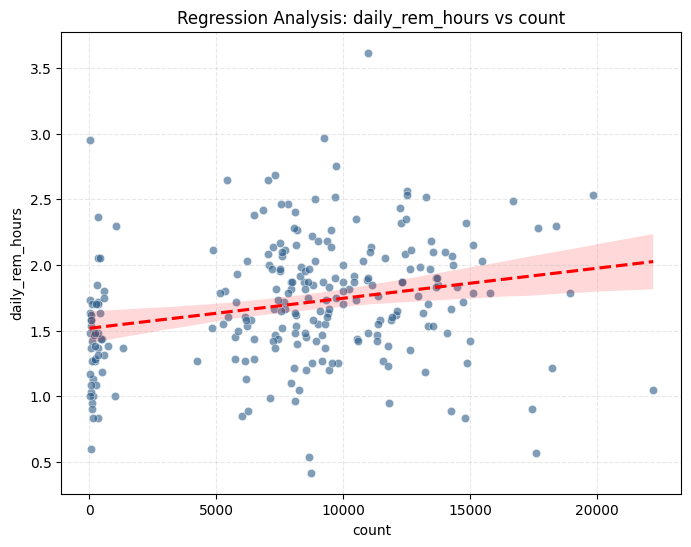

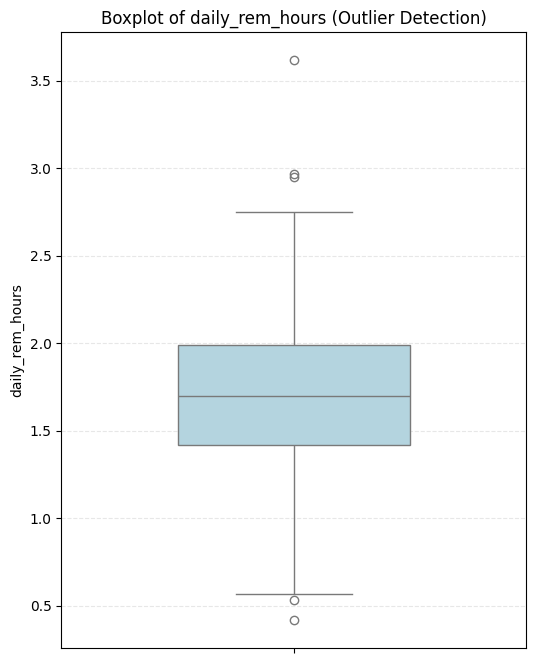

In [19]:
# Regression Line
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df[X], y=df[Y], alpha=0.6, color='#2b5c8a')
sns.regplot(x=df[X], y=df[Y], scatter=False, color='red', line_kws={'linestyle':'--'})
plt.title(f'Regression Analysis: {Y} vs {X}')
plt.xlabel(X)
plt.ylabel(Y)
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig(f'scatter_{Y}_vs_{X}.png', dpi=300, bbox_inches='tight')
plt.show()

# Boxplot Visualization
plt.figure(figsize=(6, 8))
sns.boxplot(y=df[Y], color='lightblue', width=0.5)
plt.title(f'Boxplot of {Y} (Outlier Detection)')
plt.ylabel(Y)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig(f'boxplot_{Y}.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# PARAMETER ESTIMATION

# Maximum Likelihood Estimation (MLE)
data = df[Y]
mu_mle, sigma_mle = stats.norm.fit(data)

# Method of Moment (MoM)
# For normal distribution, MoM is simply sample mean and population stddev
mu_mom = data.mean()
sigma_mom = data.std(ddof=0)

# Bayesian Estimation
mu_0 = 1.5 # From what I've seen, a healthy REM is %20-25 of the total sleep duration, this comes from 6.89*0.22
tau = 0.5       
n = len(data)

# Bayesian Update for Mean
var_data = sigma_mle**2
var_prior = tau**2
weight_prior = var_data / (n * var_prior + var_data)
weight_data = (n * var_prior) / (n * var_prior + var_data)
mu_bayes = weight_prior * mu_0 + weight_data * data.mean()

print(f"--- PARAMETER ESTIMATION ({Y}) ---")
print(f"MLE: mu={mu_mle:.4f}, sigma={sigma_mle:.4f}")
print(f"MoM: mu={mu_mom:.4f}, sigma={sigma_mom:.4f}")
print(f"Bayesian Estimate: mu={mu_bayes:.4f} (Prior: mu={mu_0}, tau={tau})")

--- PARAMETER ESTIMATION (daily_rem_hours) ---
MLE: mu=1.7023, sigma=0.4712
MoM: mu=1.7023, sigma=0.4712
Bayesian Estimate: mu=1.7016 (Prior: mu=1.5, tau=0.5)


<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/var/folders/5d/9l6gb_c515qgg88vn1bg1y340000gn/T/ipykernel_51262/1306717239.py:7: SyntaxWarning: invalid escape sequence '\m'
  'r-', linewidth=3, label=f'MLE Fit ($\mu$={mu_mle:.2f}, $\sigma$={sigma_mle:.2f})')
/var/folders/5d/9l6gb_c515qgg88vn1bg1y340000gn/T/ipykernel_51262/1306717239.py:7: SyntaxWarning: invalid escape sequence '\s'
  'r-', linewidth=3, label=f'MLE Fit ($\mu$={mu_mle:.2f}, $\sigma$={sigma_mle:.2f})')


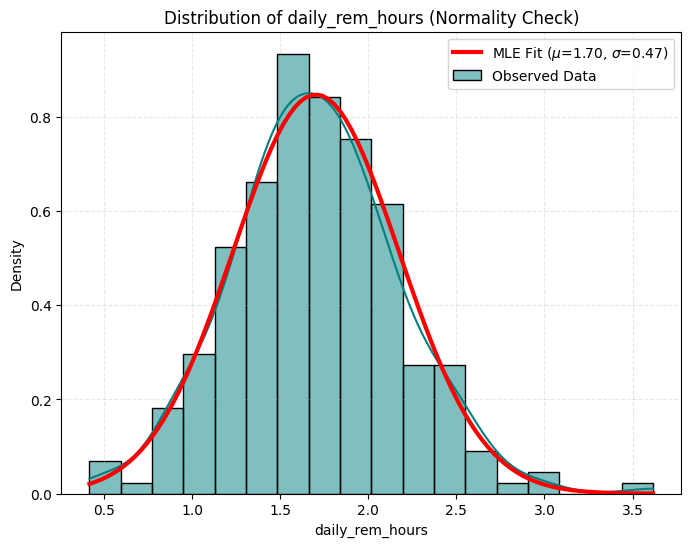

In [21]:
# Now that I have MLE, I wanted to plot it with the actual distribution to get a better visualization.
plt.figure(figsize=(8, 6))
sns.histplot(data, stat="density", kde=True, color='teal', label='Observed Data')

x_range = np.linspace(data.min(), data.max(), 100)
plt.plot(x_range, stats.norm.pdf(x_range, mu_mle, sigma_mle), 
         'r-', linewidth=3, label=f'MLE Fit ($\mu$={mu_mle:.2f}, $\sigma$={sigma_mle:.2f})')

plt.title(f'Distribution of {Y} (Normality Check)')
plt.xlabel(Y)
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

plt.savefig(f'dist_{Y}_MLE.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# GOODNESS OF FIT & HYPOTHESIS TESTING

# Applying KS Test to see if normally distributed.
ks_stat, ks_p = stats.kstest(data, 'norm', args=(mu_mle, sigma_mle))
print(f"--- GOODNESS OF FIT (KS TEST) ---")
print(f"Statistic={ks_stat:.4f}, P-Value={ks_p:.4f}")

# Hypothesis Testing 
HYPOTHESIS_BENCHMARK = 1.5 # Same with Bayesian, in the study that's what is considered to be the healthy amount.
print(f"--- HYPOTHESIS TESTING (Benchmark = {HYPOTHESIS_BENCHMARK}) ---")
alpha = 0.05

if ks_p > alpha:
    # If its normally distributed, applying t-test.
    print(f"Result: Data looks Normal (p > {alpha}). Using Parametric Test (T-Test).")
    t_stat, t_p = stats.ttest_1samp(data, HYPOTHESIS_BENCHMARK)
    print(f"One-Sample T-Test: Statistic={t_stat:.4f}, P-Value={t_p:.4f}")
else:
    print(f"Result: Data does NOT look Normal (p < {alpha}). Using Nonparametric Test (Wilcoxon).")
    # As Wilcoxon Signed Rank Test is the nonparametric alternative to one sample t-test if the distribution is not normal.
    w_stat, w_p = stats.wilcoxon(data - HYPOTHESIS_BENCHMARK)
    print(f"Wilcoxon Signed-Rank Test: Statistic={w_stat:.4f}, P-Value={w_p:.4f}")

--- GOODNESS OF FIT (KS TEST) ---
Statistic=0.0438, P-Value=0.7143
--- HYPOTHESIS TESTING (Benchmark = 1.5) ---
Result: Data looks Normal (p > 0.05). Using Parametric Test (T-Test).
One-Sample T-Test: Statistic=6.7334, P-Value=0.0000


In [23]:
# --- 5. REGRESSION ANALYSIS ---
X = sm.add_constant(df[X])
Y = df[Y]
model = sm.OLS(Y, X).fit()

print("--- REGRESSION RESULTS ---")
print(model.summary())

# R^2 only explains ~%6 of variance, it is expected by me as steps taken can't be the most informative factor.


# Intercept (b0): 1.5169
# T-stat: 26.80 | P-value: 0.000 (< 0.05)

# The baseline REM sleep (when steps = 0) is significantly different from zero.


# Slope (b1): 2.29e-05
# T-stat: 3.825 | P-value: 0.000 (< 0.05)

# We reject the null hypothesis (H0: b1 = 0)
# There is a statistically significant positive relationship between steps and REM sleep.
# For every 10000 steps, REM sleep increases by roughly 0.23 hours (0.0000229*10000).

--- REGRESSION RESULTS ---
                            OLS Regression Results                            
Dep. Variable:        daily_rem_hours   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     14.63
Date:                Mon, 29 Dec 2025   Prob (F-statistic):           0.000166
Time:                        23:52:47   Log-Likelihood:                -157.46
No. Observations:                 247   AIC:                             318.9
Df Residuals:                     245   BIC:                             325.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5169    